In [ ]:
# This R environment comes with many helpful analytics packages installed
# It is defined by the kaggle/rstats Docker image: https://github.com/kaggle/docker-rstats
# For example, here's a helpful package to load

library(dplyr)
library(ggplot2)
library(viridis) # for colorblindness friendly colors
library(car) # for VIF test
library(gridExtra) # for merging plots
library(ggcorrplot) # correlation matrix visualization
library(lmtest) # for testing of models
library(sandwich) # for robust standard errors
library(tseries) # JB test for normality

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

list.files(path = "../input")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session




Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Loading required package: viridisLite



Loading required package: carData



...

Loading required package: zoo




Attaching package: ‘zoo’




The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



[1] "housing-prices-dataset"

In [ ]:
dataset <- read.csv("/kaggle/input/housing-prices-dataset/Housing.csv")

str(dataset) # checking the structure

sum(is.na(dataset))
sum(is.null(dataset))

head(dataset[,1:2])

'data.frame':	545 obs. of  13 variables:
 $ price           : int  13300000 12250000 12250000 12215000 11410000 10850000 10150000 10150000 9870000 9800000 ...
 $ area            : int  7420 8960 9960 7500 7420 7500 8580 16200 8100 5750 ...
 $ bedrooms        : int  4 4 3 4 4 3 4 5 4 3 ...
 $ bathrooms       : int  2 4 2 2 1 3 3 3 1 2 ...
 $ stories         : int  3 4 2 2 2 1 4 2 2 4 ...
 $ mainroad        : chr  "yes" "yes" "yes" "yes" ...
 $ guestroom       : chr  "no" "no" "no" "no" ...
 $ basement        : chr  "no" "no" "yes" "yes" ...
 $ hotwaterheating : chr  "no" "no" "no" "no" ...
 $ airconditioning : chr  "yes" "yes" "no" "yes" ...
 $ parking         : int  2 3 2 3 2 2 2 0 2 1 ...
 $ prefarea        : chr  "yes" "no" "yes" "yes" ...
 $ furnishingstatus: chr  "furnished" "furnished" "semi-furnished" "furnished" ...


[1] 0

[1] 0

,price,area
,<int>,<int>
1,13300000,7420
2,12250000,8960
3,12250000,9960
4,12215000,7500
5,11410000,7420
6,10850000,7500


In [ ]:
# Prices are in millions, with the lowest price being more than a million,
# thus we transform the prices by dividing them by a factor of one million to
# induce better readability

summary(dataset$price)
price_division = 1000000

dataset <- dataset %>%
    mutate(price = price / price_division)
summary(dataset$price)

# The area of the houses is probably in square feet - to make it
# easier on the eyes of us Europeans, lets convert the units to
# square meters

summary(dataset$area)
convert_sqfeet_sqmeters <- 0.092903 # conversion factor

dataset <- dataset %>%
    mutate(area = area * convert_sqfeet_sqmeters)
summary(dataset$area)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
 1750000  3430000  4340000  4766729  5740000 13300000 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.750   3.430   4.340   4.767   5.740  13.300 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1650    3600    4600    5151    6360   16200 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  153.3   334.5   427.4   478.5   590.9  1505.0 

In [ ]:

# Dummy variables for furnishing of the home, other variables containing either
# "yes" or "no" are done the same way without the extra step

unique(dataset$furnishingstatus)
furnish_scatter_legend <- dataset$furnishingstatus

furnished_dummy <- ifelse(dataset$furnishingstatus == "furnished",1,0)
semi_furnished_dummy <- ifelse(dataset$furnishingstatus == "semi-furnished",1,0)
unfurnished_dummy <- ifelse(dataset$furnishingstatus == "unfurnished",1,0)

dataset <- dataset %>%
    select(-furnishingstatus) %>%
    mutate(
        furnished = furnished_dummy,
        semi_furnished = semi_furnished_dummy,
        unfurnished = unfurnished_dummy,
        mainroad = ifelse(mainroad == "yes",1,0),
        guestroom = ifelse(guestroom == "yes",1,0),
        basement = ifelse(basement == "yes",1,0),
        hotwaterheating = ifelse(hotwaterheating == "yes",1,0),
        airconditioning = ifelse(airconditioning == "yes",1,0),
        prefarea = ifelse(prefarea == "yes",1,0)
        ) %>%
    rename(
        water_heating = hotwaterheating,
        desirable_area = prefarea,
        air_cond = airconditioning
        )

[1] "furnished"      "semi-furnished" "unfurnished"

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   2.000   3.000   2.965   3.000   6.000 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   1.000   1.000   1.286   2.000   4.000 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   1.000   2.000   1.806   2.000   4.000 

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


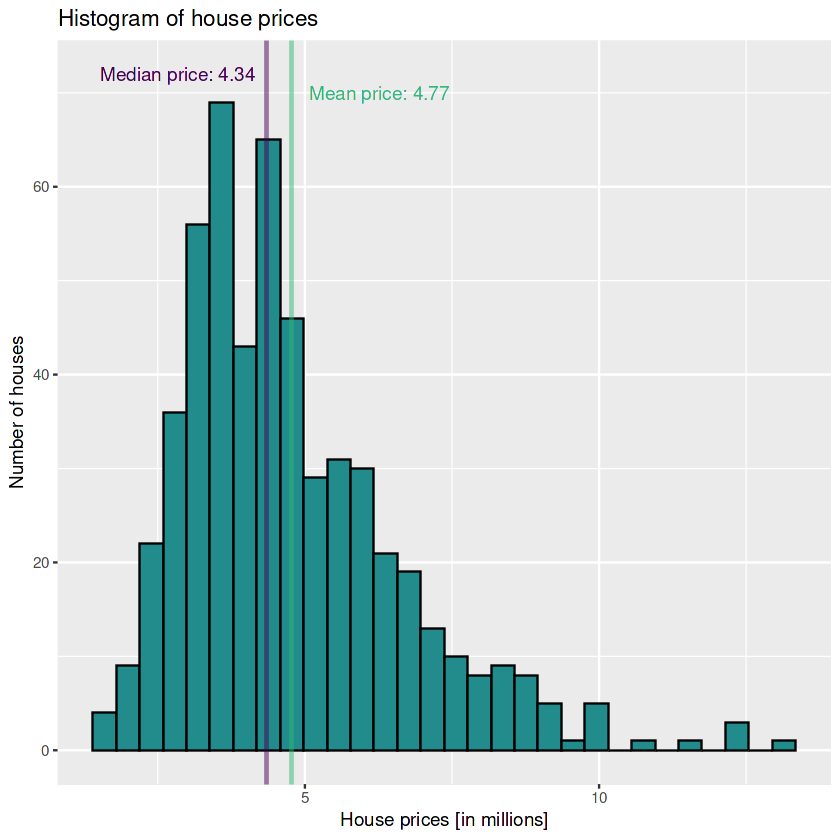

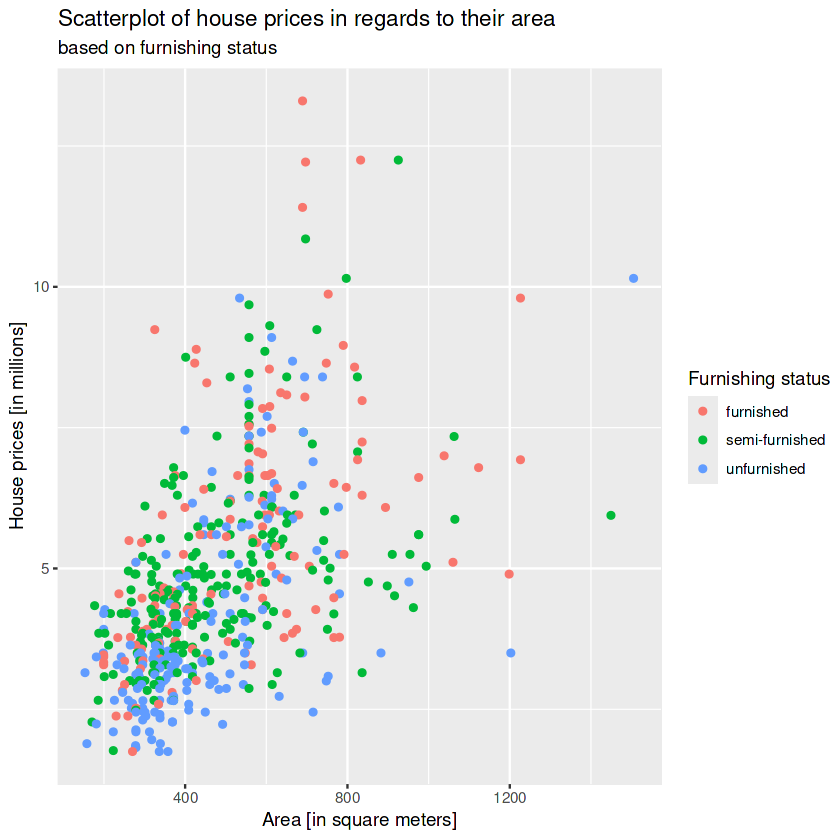

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


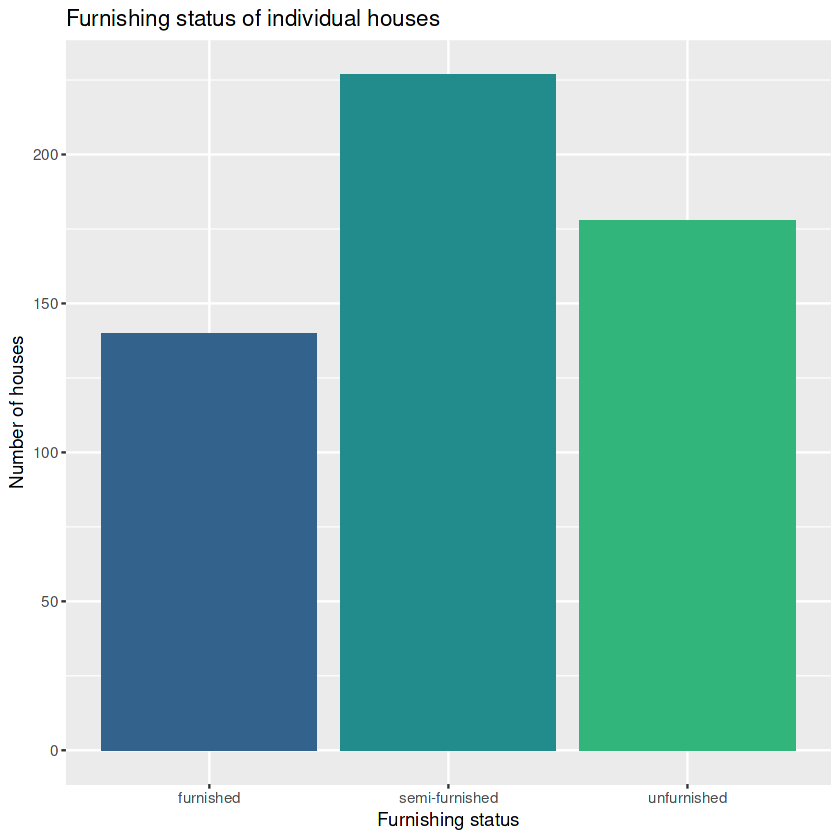

    mainroad        guestroom        basement      water_heating    
 Min.   :0.0000   Min.   :0.000   Min.   :0.0000   Min.   :0.00000  
 1st Qu.:1.0000   1st Qu.:0.000   1st Qu.:0.0000   1st Qu.:0.00000  
 Median :1.0000   Median :0.000   Median :0.0000   Median :0.00000  
 Mean   :0.8587   Mean   :0.178   Mean   :0.3505   Mean   :0.04587  
 3rd Qu.:1.0000   3rd Qu.:0.000   3rd Qu.:1.0000   3rd Qu.:0.00000  
 Max.   :1.0000   Max.   :1.000   Max.   :1.0000   Max.   :1.00000  
    air_cond         parking       desirable_area  
 Min.   :0.0000   Min.   :0.0000   Min.   :0.0000  
 1st Qu.:0.0000   1st Qu.:0.0000   1st Qu.:0.0000  
 Median :0.0000   Median :0.0000   Median :0.0000  
 Mean   :0.3156   Mean   :0.6936   Mean   :0.2349  
 3rd Qu.:1.0000   3rd Qu.:1.0000   3rd Qu.:0.0000  
 Max.   :1.0000   Max.   :3.0000   Max.   :1.0000  

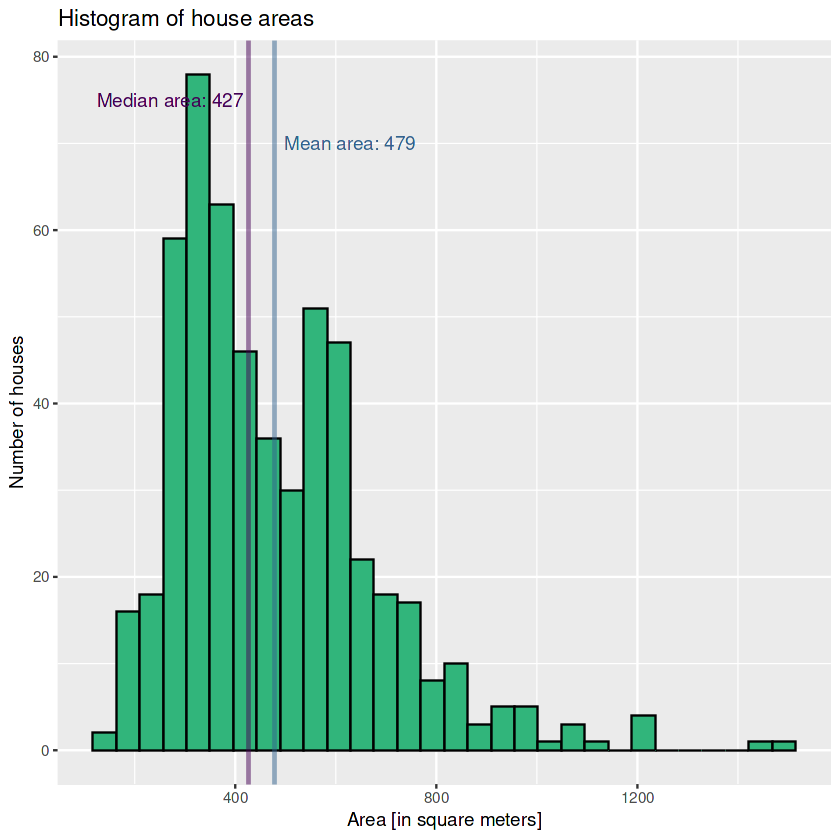

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


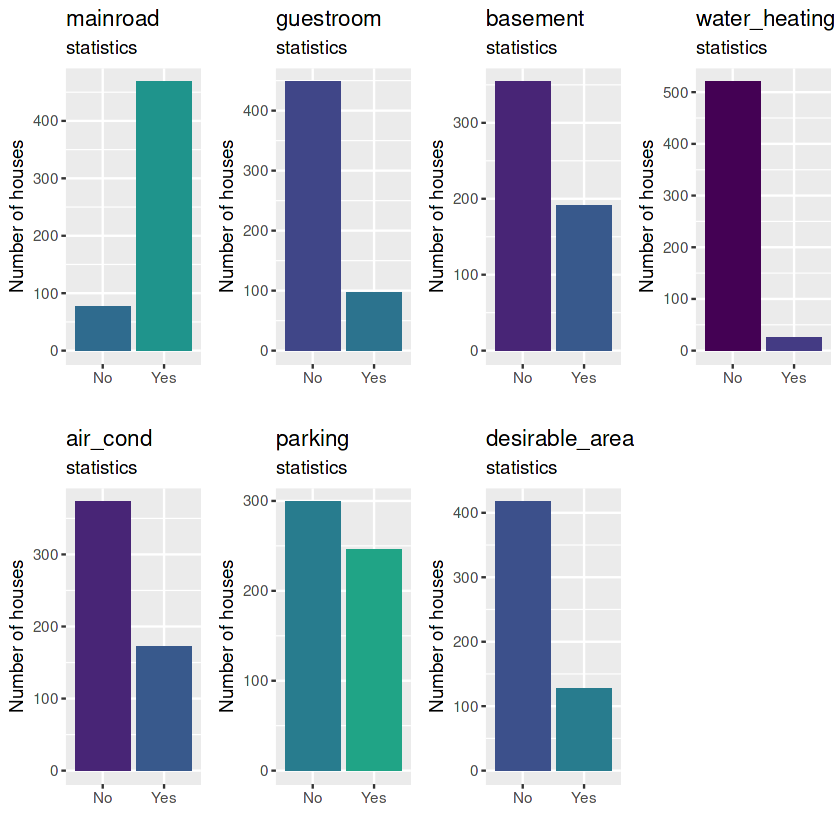

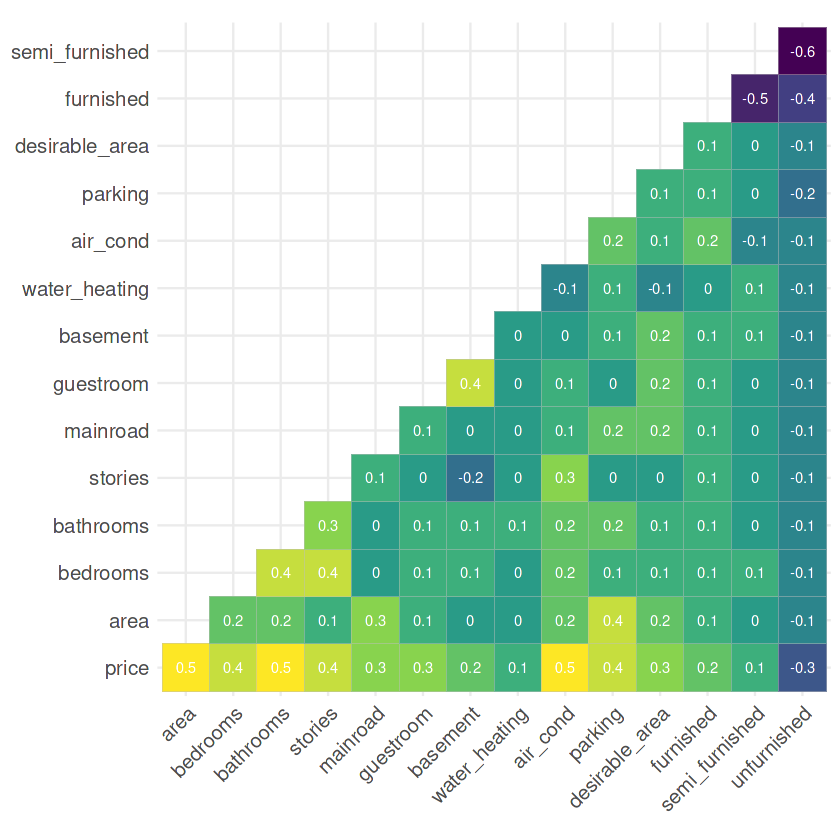

In [ ]:
# Data visualization ====
# Basic summary statistics

summary(dataset$bedrooms)
summary(dataset$bathrooms)
summary(dataset$stories)

## Price ====

ggplot(dataset, aes(x = price)) + # Histogram of price
    geom_histogram(color = "black", fill = viridis(30)[15]) +
    labs(
        title = "Histogram of house prices",
        x = "House prices [in millions]",
        y = "Number of houses"
    ) +
    geom_vline(
        xintercept = median(dataset$price),
        alpha = 0.5,
        linewidth = 1,
        color = viridis(30)[1]
    ) +
    annotate(
        "text",
        x = median(dataset$price) - 1.5,
        y = 72,
        label = paste("Median price:", round(median(dataset$price),2)),
        color = viridis(30)[1]
    ) +
    geom_vline(
        xintercept = mean(dataset$price),
        alpha = 0.5,
        linewidth = 1,
        color = viridis(30)[20]
    ) +
    annotate(
        "text",
        x = mean(dataset$price) + 1.5,
        y = 70,
        label = paste("Mean price:", round(mean(dataset$price),2)),
        color = viridis(30)[20]
    )

ggplot(dataset, aes(x = area, y = price, color = furnish_scatter_legend)) + # Scatterplot of price to area
    geom_point(size = 1.5) +
    labs(
        title = "Scatterplot of house prices in regards to their area",
        subtitle = "based on furnishing status",
        x = "Area [in square meters]",
        y = "House prices [in millions]",
        color = "Furnishing status"
    )

## Furnishing ====

furnishing_df <- data.frame(furnishing_status = factor(furnish_scatter_legend))
ggplot(furnishing_df, aes(x = furnishing_status)) +
    geom_bar(fill = c(viridis(30)[10], viridis(30)[15], viridis(30)[20])) +
    labs(
        title = "Furnishing status of individual houses",
        x = "Furnishing status",
        y = "Number of houses"
    )

## Area ====

ggplot(dataset, aes(x = area)) +
    geom_histogram(color = "black", fill = viridis(30)[20]) +
    labs(
        title = "Histogram of house areas",
        x = "Area [in square meters]",
        y = "Number of houses"
    ) +
    geom_vline(
        xintercept = median(dataset$area),
        alpha = 0.5,
        linewidth = 1,
        color = viridis(30)[1]
    ) +
    annotate(
        "text",
        x = median(dataset$area) - 157,
        y = 75,
        label = paste("Median area:", round(median(dataset$area))),
        color = viridis(30)[1]
    ) +
    geom_vline(
        xintercept = mean(dataset$area),
        alpha = 0.5,
        linewidth = 1,
        color = viridis(30)[10]
    ) +
    annotate(
        "text",
        x = mean(dataset$area) + 150,
        y = 70,
        label = paste("Mean area:", round(mean(dataset$area))),
        color = viridis(30)[10]
    )

## Indicator/binary dummy variables ====

summary(dataset[,6:12])
variable_names <- c("mainroad", "guestroom", "basement", "water_heating", "air_cond", "parking", "desirable_area")
y_n <- c("Yes", "No")
binary_variables <- setNames(lapply(variable_names, function(x) y_n), variable_names)

createBinaryPlot <- function(binary_variable, labels){
    random_coloring <- sample(1:20,1)
    binary_variable.df <- data.frame(is_present = ifelse(dataset[[binary_variable]], labels[1], labels[2]))
    plot <- ggplot(binary_variable.df, aes(x = factor(is_present))) +
        geom_bar(fill = c(viridis(30)[random_coloring],viridis(30)[random_coloring + 5])) +
        labs(
            title = paste(binary_variable),
            subtitle = "statistics",
            x = "",
            y = "Number of houses",
        )
    return(plot)
}

bar_graph_list <- list()
for (variable_name in names(binary_variables)) {
    bar_graph_list[[variable_name]] <- createBinaryPlot(variable_name, binary_variables[[variable_name]])
}

grid.arrange(grobs = bar_graph_list, ncol = 4, nrow = 2)

## Correlation matrix ====

ggcorrplot(cor(dataset),
           digits = 1,
           lab = TRUE,
           type = "lower",
           lab_size = 3,
           lab_col = "white",
           show.legend = FALSE) +
    scale_fill_viridis_c()


Call:
lm(formula = price ~ . - furnished, data = dataset)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.6197 -0.6573 -0.0684  0.5072  5.1667 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     0.0427717  0.2643133   0.162 0.871508    
area            0.0026279  0.0002614  10.052  < 2e-16 ***
bedrooms        0.1147876  0.0725987   1.581 0.114445    
bathrooms       0.9876681  0.1033620   9.555  < 2e-16 ***
stories         0.4508480  0.0641689   7.026 6.55e-12 ***
mainroad        0.4212726  0.1422241   2.962 0.003193 ** 
guestroom       0.3005259  0.1317102   2.282 0.022901 *  
basement        0.3501069  0.1102841   3.175 0.001587 ** 
water_heating   0.8554471  0.2231527   3.833 0.000141 ***
air_cond        0.8649583  0.1083545   7.983 8.91e-15 ***
parking         0.2771071  0.0585259   4.735 2.82e-06 ***
desirable_area  0.6515438  0.1156823   5.632 2.89e-08 ***
semi_furnished -0.0463446  0.1165741  -0.398 0.691118    
unfurnished    -0.41


Call:
lm(formula = price ~ . - furnished - semi_furnished - bedrooms, 
    data = dataset)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.6208 -0.6987 -0.0654  0.5109  5.2317 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     0.2335704  0.2024675   1.154 0.249173    
area            0.0026637  0.0002607  10.219  < 2e-16 ***
bathrooms       1.0247697  0.1008083  10.166  < 2e-16 ***
stories         0.4868917  0.0601034   8.101 3.74e-15 ***
mainroad        0.3960926  0.1411012   2.807 0.005181 ** 
guestroom       0.2974793  0.1316845   2.259 0.024285 *  
basement        0.3739569  0.1093059   3.421 0.000671 ***
water_heating   0.8599929  0.2232011   3.853 0.000131 ***
air_cond        0.8670051  0.1079637   8.031 6.25e-15 ***
parking         0.2841869  0.0583956   4.867 1.50e-06 ***
desirable_area  0.6568581  0.1156610   5.679 2.23e-08 ***
unfurnished    -0.3894142  0.1010831  -3.852 0.000131 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘

area      bathrooms        stories       mainroad      guestroom 
      1.315645       1.222358       1.295136       1.152892       1.210904 
      basement  water_heating       air_cond        parking desirable_area 
      1.298119       1.040702       1.201665       1.205989       1.147388 
   unfurnished 
      1.072589

[1] 5.098754e-17

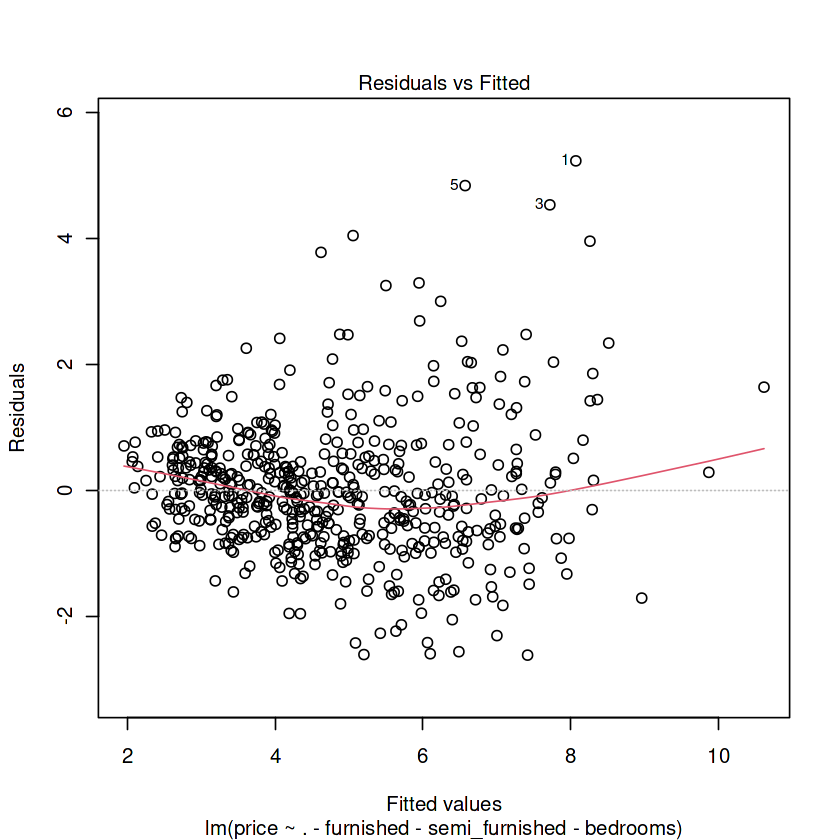


	Shapiro-Wilk normality test

data:  residuals(Model_A)
W = 0.9514, p-value = 2.105e-12



	Jarque Bera Test

data:  residuals(Model_A)
X-squared = 279.94, df = 2, p-value < 2.2e-16


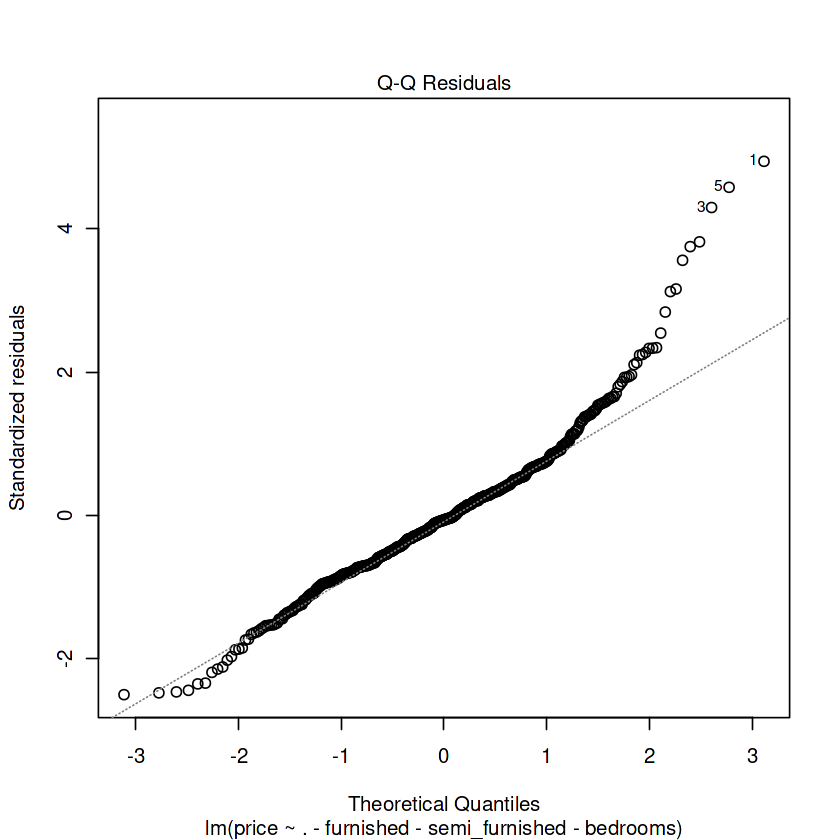


	studentized Breusch-Pagan test

data:  Model_A
BP = 63.662, df = 11, p-value = 1.922e-09



	RESET test

data:  Model_A
RESET = 22.886, df1 = 1, df2 = 532, p-value = 2.229e-06



	RESET test

data:  Model_A
RESET = 10.757, df1 = 1, df2 = 532, p-value = 0.001107


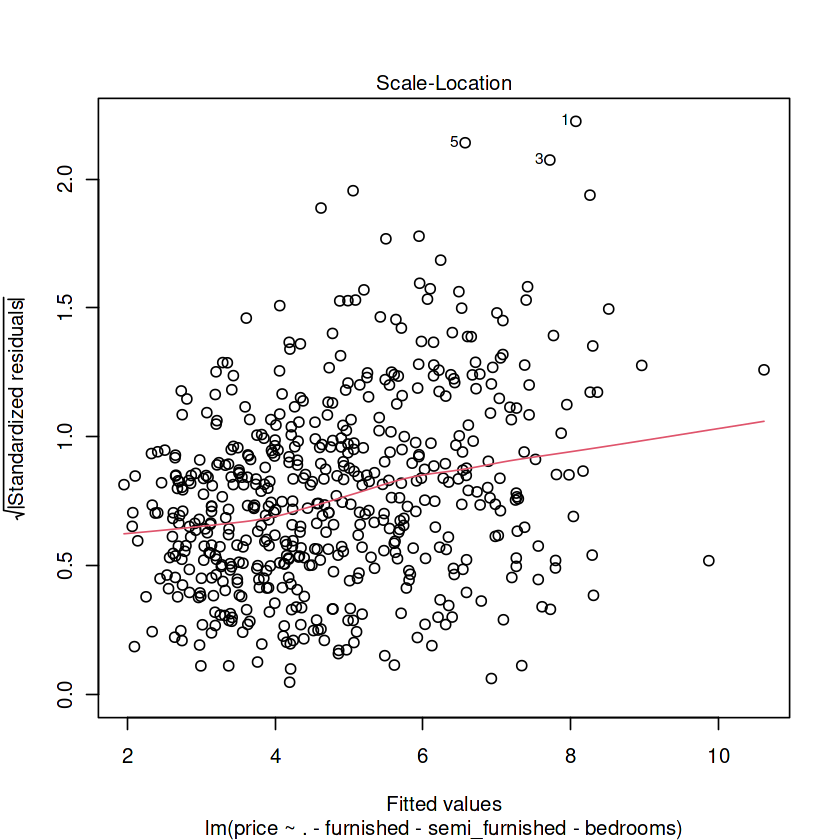

In [ ]:
# Linear model using OLS ====
## Model A ====

# We're going to be modelling against furnished houses, otherwise
# perfect multicollinearity would occur

summary(Model_A <- lm(price ~ . - furnished, data = dataset))

# One by one we dismiss variables with p-values higher than 0.05,
# starting from the biggest one

summary(Model_A <- lm(price ~ . - furnished - semi_furnished - bedrooms, data = dataset))

### Multicollinearity ====
# VIF test for multicollinearity, if any value is higher than 10
# (or 5 for a stricter comparison), there might be a multicollinearity
# present in our model

vif(Model_A)

### Other assumptions ====

# E(epsilon) = 0 looks wrong, should be linear along 0,
# the graph looks like a funnel - there is a pattern

plot(Model_A, which = 1)
mean(residuals(Model_A))

# Q-Q plot for normality, looks wrong as well

plot(Model_A, which = 2)

# test for normality, based on p-value
# data is not normally distributed

shapiro.test(residuals(Model_A))
jarque.bera.test(residuals(Model_A))

# Homoskedasticity graph - heteroskedasticity present
# because of significant relation between fitted and residuals

plot(Model_A, which = 3)

# Test for homoskedasticity, low p-value indicates
# heteroskedasticity present

bptest(Model_A)

### RESET test ====

# Overall, the model fails at everything, there must be a problem with the data
# We can try to test the overall specification of the model using a RESET test

resettest(Model_A, power = 2)
resettest(Model_A, power = 3)

# Small p-value suggests misspecified model that has a problem with it's data

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



Call:
lm(formula = log_orig_price ~ . - furnished - semi_furnished, 
    data = dataset_log_price)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.60785 -0.12756  0.00711  0.13201  0.63657 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     1.437e+01  4.804e-02 299.077  < 2e-16 ***
area            5.314e-04  5.055e-05  10.511  < 2e-16 ***
bedrooms        2.961e-02  1.404e-02   2.108  0.03548 *  
bathrooms       1.629e-01  1.999e-02   8.147 2.68e-15 ***
stories         8.993e-02  1.241e-02   7.246 1.52e-12 ***
mainroad        1.165e-01  2.749e-02   4.239 2.64e-05 ***
guestroom       6.913e-02  2.547e-02   2.714  0.00686 ** 
basement        8.932e-02  2.134e-02   4.186 3.32e-05 ***
water_heating   1.641e-01  4.316e-02   3.803  0.00016 ***
air_cond        1.733e-01  2.088e-02   8.301 8.58e-16 ***
parking         4.452e-02  1.132e-02   3.933 9.49e-05 ***
desirable_area  1.261e-01  2.237e-02   5.640 2.77e-08 ***
unfurnished    -1.215e-01  

area       bedrooms      bathrooms        stories       mainroad 
      1.323832       1.369274       1.286086       1.477447       1.170628 
     guestroom       basement  water_heating       air_cond        parking 
      1.211541       1.323050       1.041047       1.201810       1.211861 
desirable_area    unfurnished 
      1.147876       1.075423

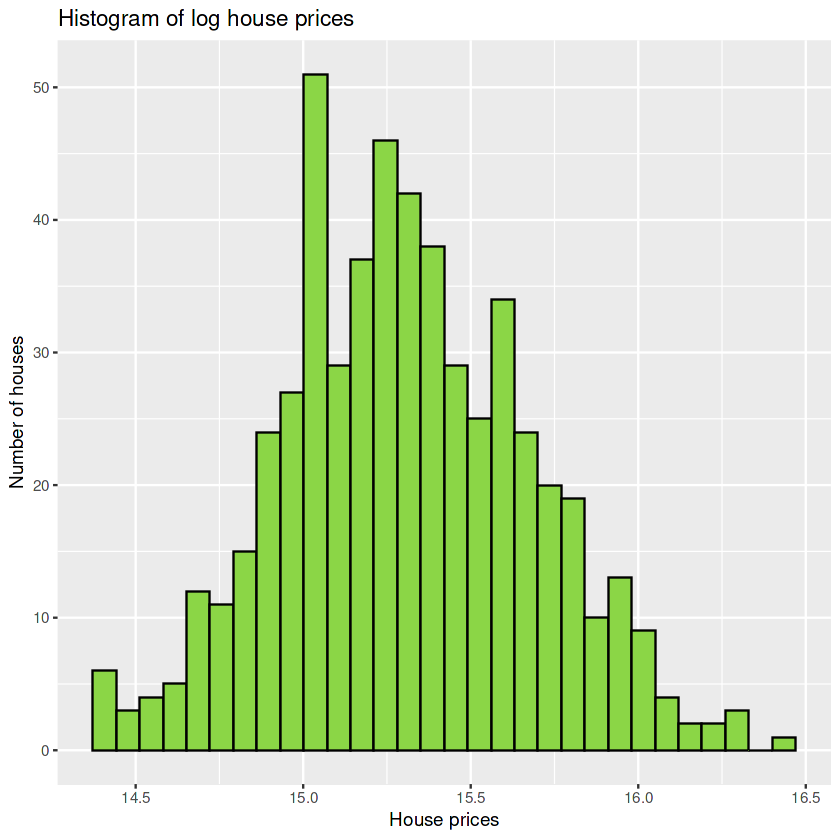

[1] 4.510679e-18

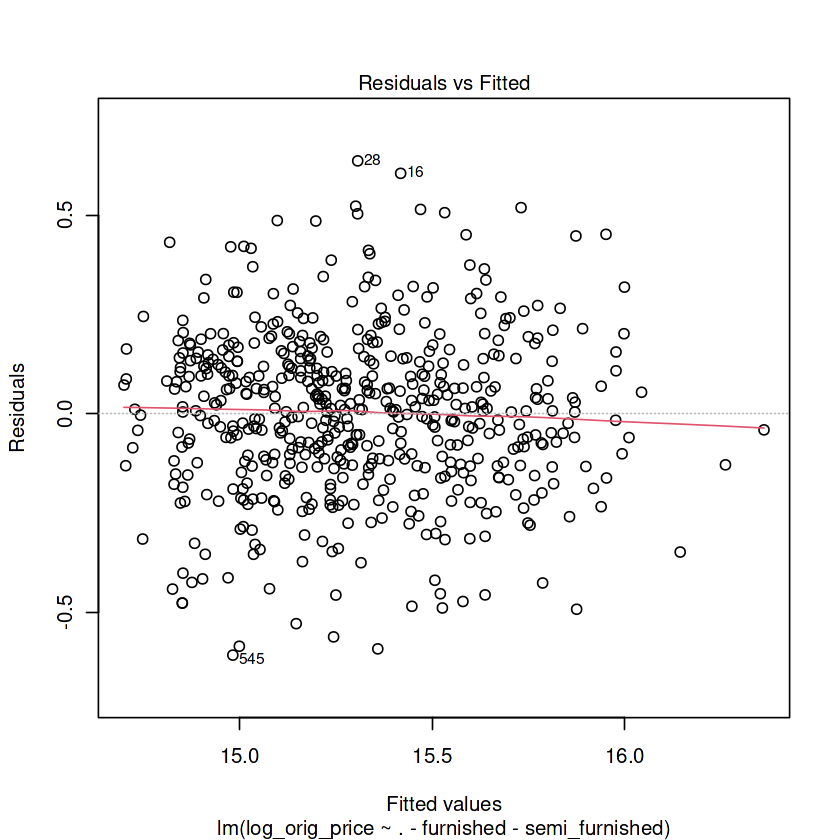


	Shapiro-Wilk normality test

data:  residuals(Model_B)
W = 0.99482, p-value = 0.06319



	Jarque Bera Test

data:  residuals(Model_B)
X-squared = 3.7756, df = 2, p-value = 0.1514


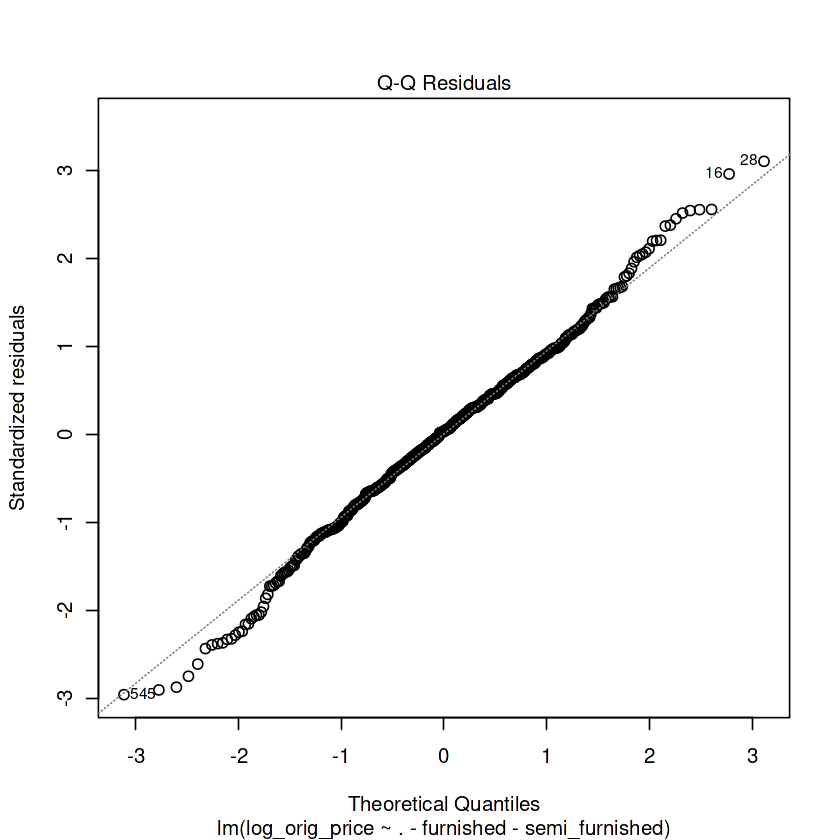


	studentized Breusch-Pagan test

data:  Model_B
BP = 28.32, df = 12, p-value = 0.004965



	RESET test

data:  Model_B
RESET = 0.7632, df1 = 1, df2 = 531, p-value = 0.3827



	RESET test

data:  Model_B
RESET = 0.27989, df1 = 1, df2 = 531, p-value = 0.597



t test of coefficients:

                  Estimate  Std. Error  t value  Pr(>|t|)    
(Intercept)     1.4366e+01  4.5129e-02 318.3397 < 2.2e-16 ***
area            5.3138e-04  5.1206e-05  10.3773 < 2.2e-16 ***
bedrooms        2.9608e-02  1.3886e-02   2.1322 0.0334467 *  
bathrooms       1.6288e-01  2.1279e-02   7.6544 9.198e-14 ***
stories         8.9931e-02  1.1614e-02   7.7431 4.929e-14 ***
mainroad        1.1655e-01  2.6845e-02   4.3415 1.695e-05 ***
guestroom       6.9126e-02  2.5460e-02   2.7151 0.0068412 ** 
basement        8.9318e-02  2.3268e-02   3.8387 0.0001386 ***
water_heating   1.6415e-01  5.2493e-02   3.1270 0.0018625 ** 
air_cond        1.7329e-01  2.0627e-02   8.4009 4.056e-16 ***
parking         4.4517e-02  1.1455e-02   3.8862 0.0001147 ***
desirable_area  1.2615e-01  2.1614e-02   5.8364 9.278e-09 ***
unfurnished    -1.2155e-01  2.0186e-02  -6.0216 3.223e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


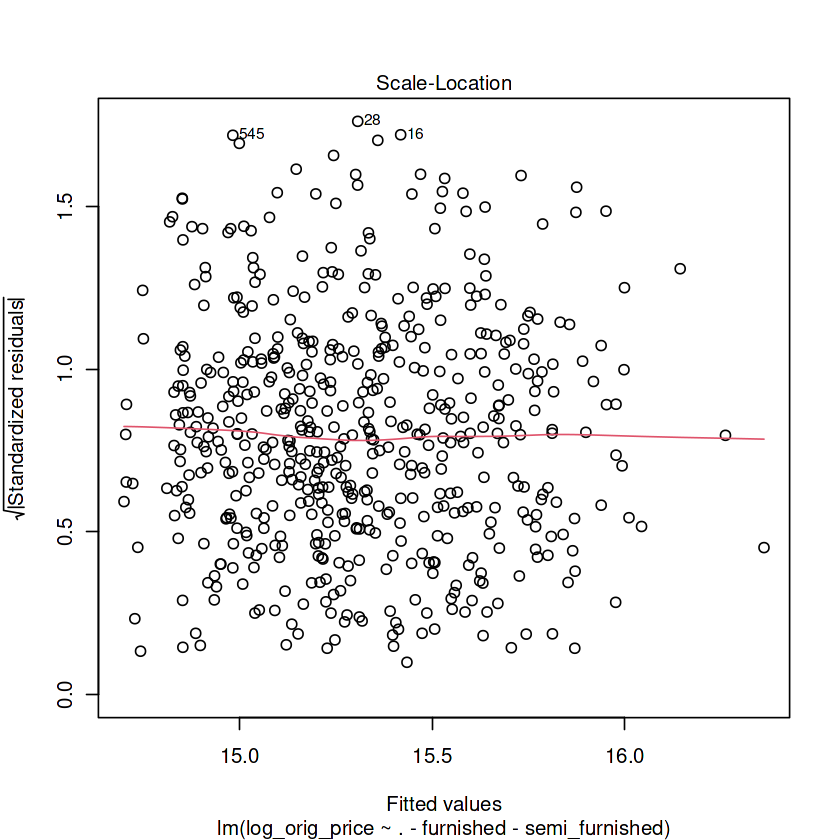

In [ ]:
## Model B ====

# Based on problematically specified Model A and on very big values of price,
# we try to logarithm the price, in hopes of improving the overall specification

# Creation and visualization of the logarithm of original price

dataset_log_price <- dataset %>%
    mutate(log_orig_price = log(price * price_division)) %>%
    select(-price)

ggplot(dataset_log_price, aes(x = log_orig_price)) +
    geom_histogram(color = "black", fill = viridis(30)[25]) +
    labs(
        title = "Histogram of log house prices",
        x = "House prices",
        y = "Number of houses"
    )

summary(Model_B <- lm(log_orig_price ~ . - furnished - semi_furnished, data = dataset_log_price))

### Assumptions with multicollinearity and RESET test ====

# We test for the same assumptions, normality and expected value of random errors
# look fine along with VIF, we do have heteroskedasticity based on Breuch-Pagan test though

vif(Model_B)

plot(Model_B, which = 1)
mean(residuals(Model_B))

plot(Model_B, which = 2)
shapiro.test(residuals(Model_B))
jarque.bera.test(residuals(Model_B))

plot(Model_B, which = 3)

bptest(Model_B)

# Lastly we check for the overall specification of the model, which looks good now

resettest(Model_B, power = 2)
resettest(Model_B, power = 3)

# To try and avoid the heteroskedasticity, we use robust standart errors HC1

robust_se_Model_B <- vcovHC(Model_B, type = "HC1")
coeftest(Model_B, vcov = robust_se_Model_B)


Call:
lm(formula = log_orig_price ~ . - furnished - semi_furnished - 
    unfurnished - desirable_area + mainroad:parking - parking + 
    water_heating:air_cond, data = dataset_log_price)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.70775 -0.13136  0.01427  0.14671  0.64190 

Coefficients:
                         Estimate Std. Error t value Pr(>|t|)    
(Intercept)             1.426e+01  4.862e-02 293.330  < 2e-16 ***
area                    5.838e-04  5.291e-05  11.033  < 2e-16 ***
bedrooms                3.609e-02  1.485e-02   2.430 0.015439 *  
bathrooms               1.645e-01  2.118e-02   7.766 4.17e-14 ***
stories                 9.462e-02  1.315e-02   7.196 2.11e-12 ***
mainroad                1.371e-01  2.942e-02   4.658 4.03e-06 ***
guestroom               8.034e-02  2.697e-02   2.979 0.003022 ** 
basement                1.220e-01  2.214e-02   5.510 5.60e-08 ***
water_heating           1.785e-01  4.670e-02   3.821 0.000148 ***
air_cond                1.839e-

there are higher-order terms (interactions) in this model
consider setting type = 'predictor'; see ?vif



area               bedrooms              bathrooms 
              1.291031               1.363240               1.284448 
               stories               mainroad              guestroom 
              1.475777               1.193368               1.209155 
              basement          water_heating               air_cond 
              1.267933               1.084781               1.211988 
      mainroad:parking water_heating:air_cond 
              1.268232               1.063001

Warning message:
“not plotting observations with leverage one:
  379”


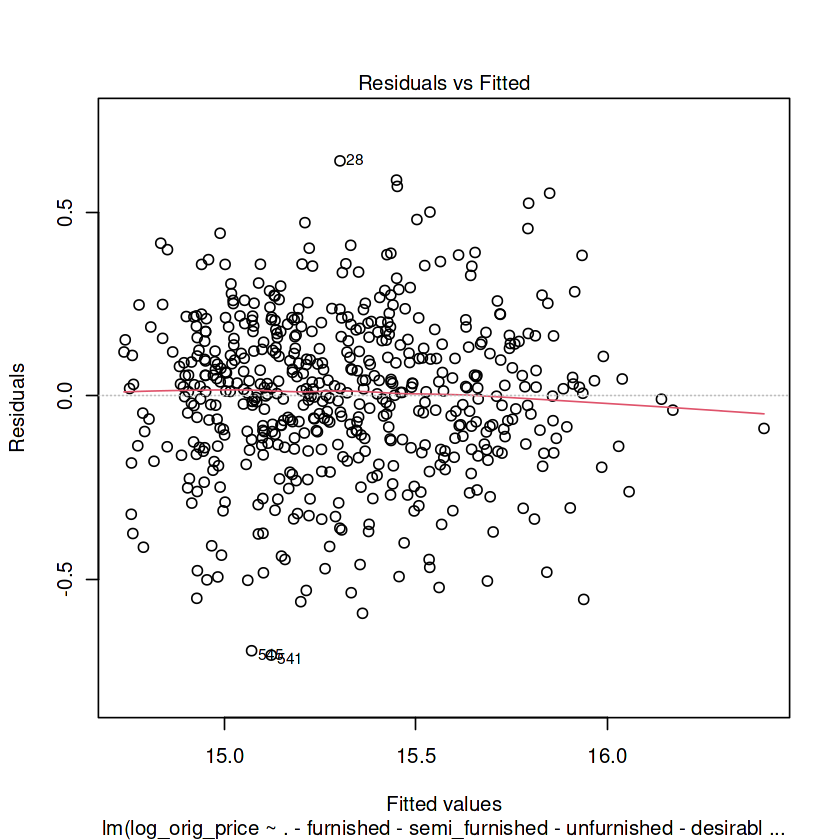


	Shapiro-Wilk normality test

data:  residuals(Model_C)
W = 0.99091, p-value = 0.001958



	Jarque Bera Test

data:  residuals(Model_C)
X-squared = 10.865, df = 2, p-value = 0.004372


Warning message:
“not plotting observations with leverage one:
  379”


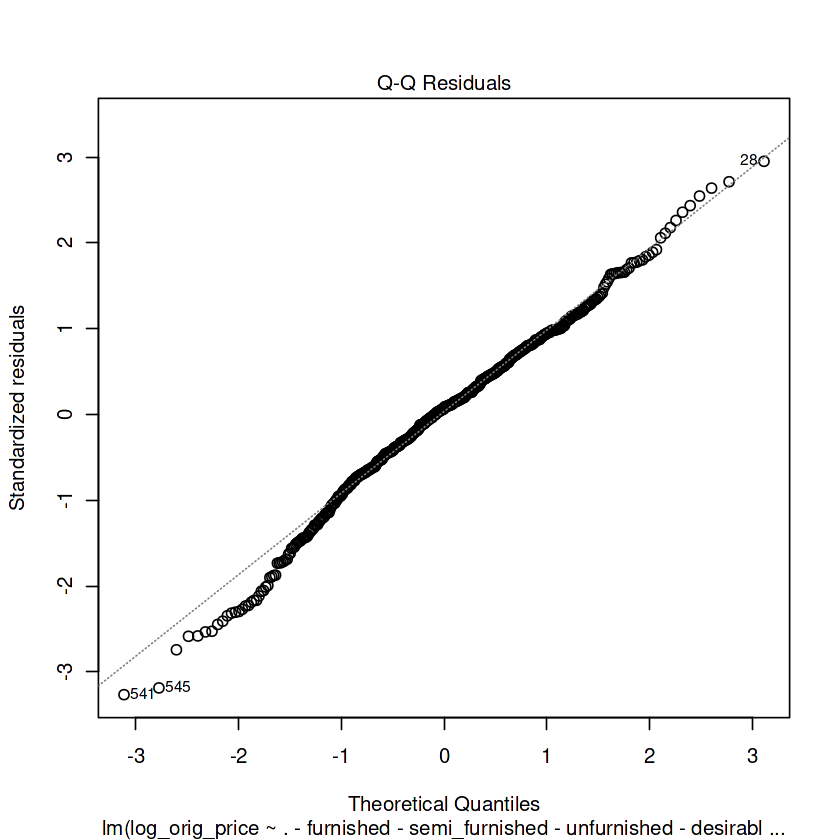


	studentized Breusch-Pagan test

data:  Model_C
BP = 16.284, df = 11, p-value = 0.1309



	RESET test

data:  Model_C
RESET = 0.53677, df1 = 1, df2 = 532, p-value = 0.4641



	RESET test

data:  Model_C
RESET = 0.5138, df1 = 1, df2 = 532, p-value = 0.4738


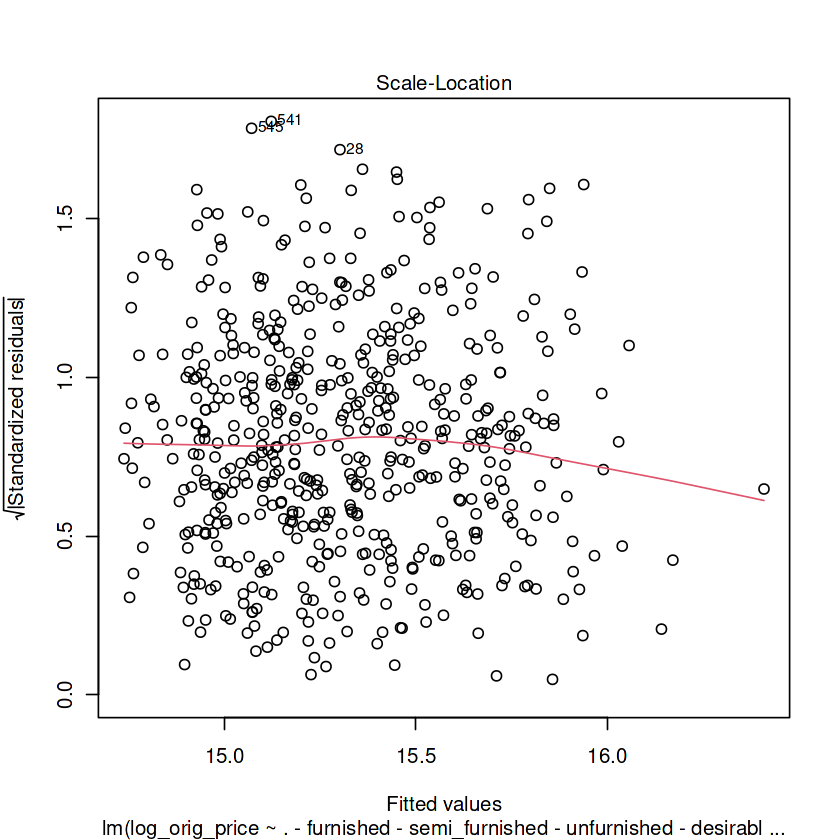

In [ ]:
## Model C ====

# We add interaction terms so we can test our hypotheses

summary(Model_C <- lm(log_orig_price ~ . - furnished - semi_furnished - unfurnished
                      - desirable_area + mainroad:parking - parking + water_heating:air_cond, data = dataset_log_price))

### Assumptions with multicollinearity and RESET test ====

# Everything is the same as in Model B

vif(Model_C)

plot(Model_C, which = 1)

plot(Model_C, which = 2)
shapiro.test(residuals(Model_C))
jarque.bera.test(residuals(Model_C))

plot(Model_C, which = 3)
bptest(Model_C) # Heteroskedasticity is fixed without the need for HCE

resettest(Model_C, power = 2)
resettest(Model_C, power = 3)

In [ ]:
# Hypothesis testing ====

## First hypothesis ====
# Function using the car package

test <- linearHypothesis(Model_C, "mainroad:parking - water_heating:air_cond = 0")
p_value_1 <- test$`Pr(>F)`[2]

# The same p-value using manual matrix/vector operations

beta_hat <- coefficients(Model_C)
beta_hat[11] - beta_hat[12]

a <- c(rep(0,10), 1, -1)

t_stat <- t(a) %*% beta_hat/sqrt(t(a) %*% vcov(Model_C) %*% a)
p_value_2 <- 2 * pt(-abs(t_stat), df=summary(Model_C)$df[2])

are_p_values_same <- near(p_value_1, p_value_2) # Checks if they are close enough
paste("Are p-values the same?", are_p_values_same)

# Both were for the question of them being equal,
# we want to test, if mainroad:parking impacts the price more than
# water_heating:air_cond, so we use a right-side hypothesis

(right_side_p <-1 - pt(t_stat, df=summary(Model_C)$df[2]))

# or

t_stat > qt(0.95,df=summary(Model_C)$df[2]) # If true, we reject H_0

## Second hypothesis ====

a_2 <- c(0, 0, 1, -1, rep(0,8))

t_stat_2 <- t(a_2) %*% beta_hat/sqrt(t(a_2) %*% vcov(Model_C) %*% a_2)

t_stat_2 < qt(0.05,df=summary(Model_C)$df[2])

test2 <- linearHypothesis(Model_C, "bedrooms - bathrooms = 0")
(p_value_second_hyp <- test2$`Pr(>F)`[2] / 2) # We reject H_0

mainroad:parking 
       0.3880153

[1] "Are p-values the same? TRUE"

0.04316432


TRUE


TRUE


[1] 4.038607e-06